In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (mean_absolute_error,mean_squared_error)

In [2]:
model_df=pd.read_csv(r"C:\Users\ganesh\Desktop\All Projects\Predicative care load Forecasting\data\processed\hhs_feature.csv")

In [3]:
model_df["Date"]= pd.to_datetime(model_df["Date"])

In [4]:
model_df= model_df.sort_values("Date").reset_index(drop=True)

In [ ]:
target="Children in HHS Care"

y=model_df[["Date",target]].copy()

In [6]:
y.head()

,Date,Children in HHS Care
0,2023-01-12,6566
1,2023-01-22,7122
2,2023-01-23,7280
3,2023-01-24,7433
4,2023-01-25,7538


In [7]:
y.tail()

,Date,Children in HHS Care
715,2025-12-15,2470
716,2025-12-16,2468
717,2025-12-17,2481
718,2025-12-18,2472
719,2025-12-21,2484


In [9]:
split_index=int(len(y) * 0.80)

train=y.iloc[:split_index].copy()
test=y.iloc[split_index:].copy()

print("Training observation:",len(train))
print("Testing observation:",len(test))

Training observation: 576
Testing observation: 144


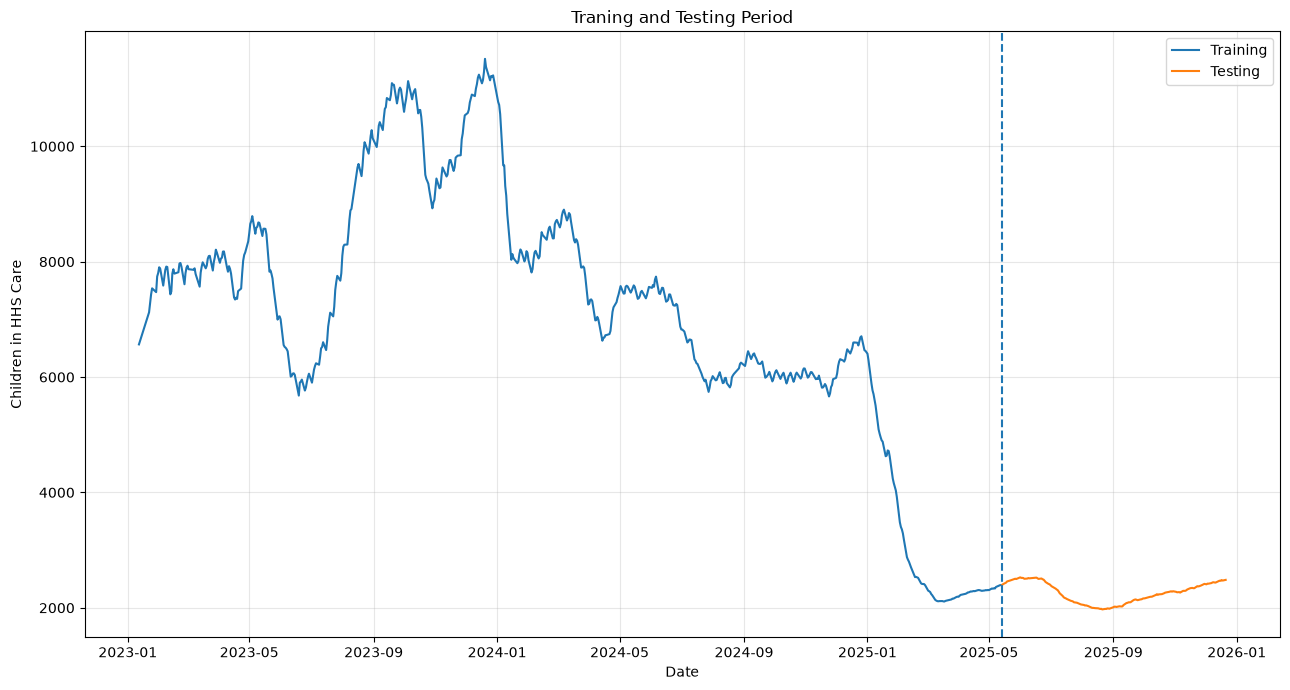

In [11]:
plt.figure(figsize=(13,7))

plt.plot(
    train["Date"],
    train[target],
    label="Training"
)

plt.plot(
    test["Date"],
    test[target],
    label="Testing"
)

plt.axvline(
    test["Date"].iloc[0],
    linestyle="--"
)

plt.title("Traning and Testing Period")
plt.xlabel("Date")
plt.ylabel("Children in HHS Care")
plt.legend()
plt.tight_layout()
plt.grid(alpha=0.3)
plt.show()



In [12]:
naive_predication=np.repeat(
    train[target].iloc[-1],
    len(test)
)

In [13]:
naive_mae=mean_absolute_error(
    test[target],
    naive_predication
)

print("Naive MAE:",naive_mae)

Naive MAE: 186.50694444444446


In [14]:
naive_rmse=np.sqrt(
    mean_squared_error(
        test[target],
        naive_predication
    )
)

print("Naive RMSE:",naive_rmse)

Naive RMSE: 227.22854684216065


In [15]:
window=7
moving_average_predication=np.repeat(
    train[target].tail(window).mean(),
    len(test)
)

In [16]:
ma_mae=mean_absolute_error(
    test[target],
    moving_average_predication
)

ma_rmse=np.sqrt(
    mean_squared_error(
        test[target],
        moving_average_predication
    )
)

print("Moving Average MAE:",ma_mae)
print("Moving Average RMSE:",ma_rmse)

Moving Average MAE: 174.73313492063497
Moving Average RMSE: 208.66256400685262
